<a href="https://colab.research.google.com/github/lakmg2007/SCALAR_LEARNINGS/blob/main/Country_Segmentation_Case_Study_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Country Segmentation Case Study

This Google Colab notebook solves the country socio-economic segmentation case study using:

- Data preprocessing and EDA
- IQR-based outlier capping
- StandardScaler feature scaling
- PCA dimensionality reduction
- K-Means, Hierarchical Clustering, and DBSCAN
- Cluster comparison and business recommendations

**Dataset required:** `Country-data.csv`

## 1. Install and Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

## 2. Load Dataset

Run the upload cell and select `Country-data.csv`.

In [3]:
df = pd.read_csv('/content/Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Problem Statement and Objective

The objective is to analyze socio-economic indicators of countries and identify meaningful country segments. These segments can help prioritize policy support, aid allocation, and development strategies.

The analysis uses clustering because there is no predefined target label. PCA is used to reduce dimensionality and visualize country patterns more clearly.

## 4. Initial Data Inspection

In [5]:
print('Shape:', df.shape)
print('Data types:')
print(df.dtypes)

print('Missing values:')
print(df.isnull().sum())

print('Summary statistics:')
df.describe().T

Shape: (167, 10)
Data types:
country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object
Missing values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64
Summary statistics:


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


## 5. Dataset Feature Meaning

- `country`: country name
- `child_mort`: deaths of children under 5 per 1000 live births
- `exports`: exports as % of GDP
- `health`: health spending as % of GDP
- `imports`: imports as % of GDP
- `income`: net income per person
- `inflation`: annual CPI growth rate
- `life_expec`: life expectancy
- `total_fer`: total fertility rate
- `gdpp`: GDP per capita

## 6. Exploratory Data Analysis

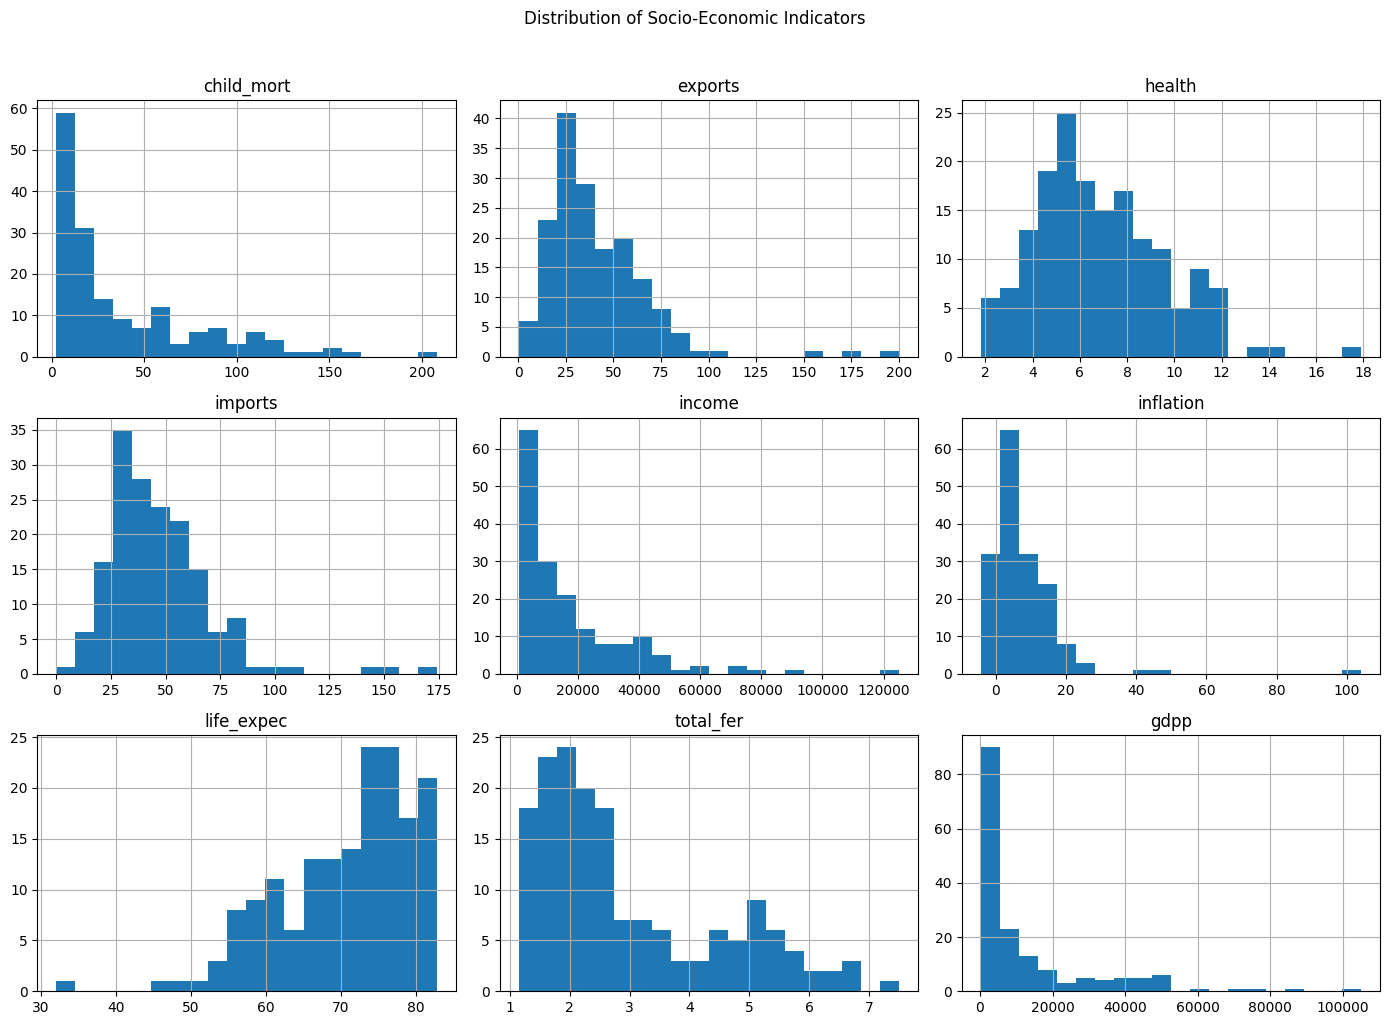

In [6]:
features = [col for col in df.columns if col != 'country']

# Histograms
df[features].hist(figsize=(14, 10), bins=20)
plt.suptitle('Distribution of Socio-Economic Indicators', y=1.02)
plt.tight_layout()
plt.show()

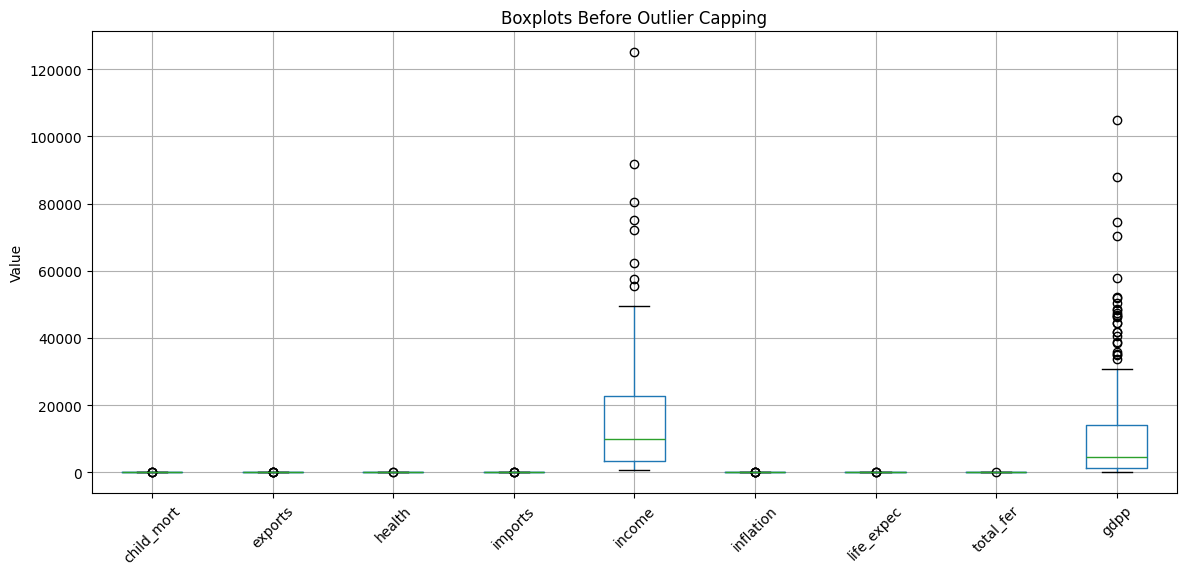

In [7]:
# Boxplots for outlier inspection
plt.figure(figsize=(14, 6))
df[features].boxplot(rot=45)
plt.title('Boxplots Before Outlier Capping')
plt.ylabel('Value')
plt.show()

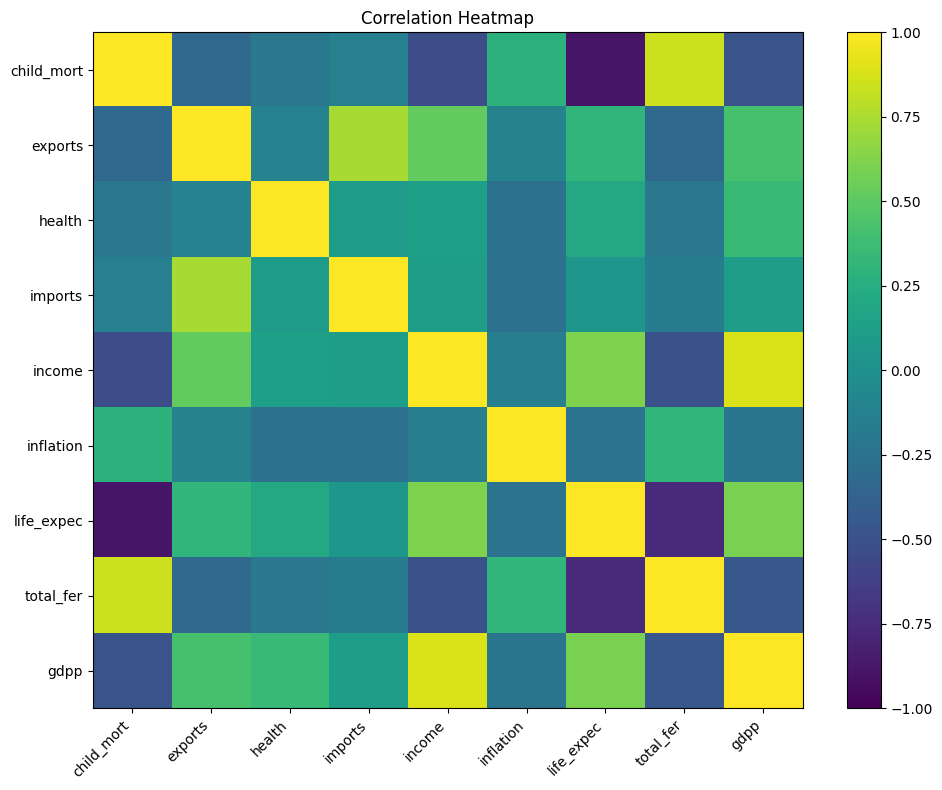

In [8]:
# Correlation heatmap
corr = df[features].corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect='auto', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(features)), features, rotation=45, ha='right')
plt.yticks(range(len(features)), features)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [9]:
print('Top 5 countries by child mortality:')
display(df.nlargest(5, 'child_mort')[['country', 'child_mort']])

print('Bottom 5 countries by GDPP:')
display(df.nsmallest(5, 'gdpp')[['country', 'gdpp']])

print('Top 5 countries by GDPP:')
display(df.nlargest(5, 'gdpp')[['country', 'gdpp']])

print('Top 5 countries by life expectancy:')
display(df.nlargest(5, 'life_expec')[['country', 'life_expec']])

Top 5 countries by child mortality:


,country,child_mort
66,Haiti,208.0
132,Sierra Leone,160.0
32,Chad,150.0
31,Central African Republic,149.0
97,Mali,137.0


Bottom 5 countries by GDPP:


,country,gdpp
26,Burundi,231
88,Liberia,327
37,"Congo, Dem. Rep.",334
112,Niger,348
132,Sierra Leone,399


Top 5 countries by GDPP:


,country,gdpp
91,Luxembourg,105000
114,Norway,87800
145,Switzerland,74600
123,Qatar,70300
44,Denmark,58000


Top 5 countries by life expectancy:


,country,life_expec
77,Japan,82.8
133,Singapore,82.7
145,Switzerland,82.2
7,Australia,82.0
68,Iceland,82.0


## 7. Outlier Handling using IQR Capping

Extreme values can affect clustering and PCA. Here, IQR capping is used to reduce the influence of extreme values while still preserving the relative country pattern.

**Business caution:** For aid-related analysis, extreme poor-performing countries should not be completely removed because they may represent the countries most in need.

In [10]:
def iqr_cap(data, cols):
    capped = data.copy()
    bounds = {}
    for col in cols:
        q1 = capped[col].quantile(0.25)
        q3 = capped[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        bounds[col] = {
            'lower': lower,
            'upper': upper,
            'low_outliers': int((capped[col] < lower).sum()),
            'high_outliers': int((capped[col] > upper).sum())
        }
        capped[col] = capped[col].clip(lower=lower, upper=upper)
    return capped, bounds

X = df[features].copy()
X_capped, outlier_bounds = iqr_cap(X, features)

pd.DataFrame(outlier_bounds).T

,lower,upper,low_outliers,high_outliers
child_mort,-72.5250,142.8750,0.0,4.0
exports,-17.5250,92.6750,0.0,5.0
health,-0.6000,14.1200,0.0,2.0
imports,-12.6250,101.5750,0.0,4.0
income,-25812.5000,51967.5000,0.0,8.0
inflation,-11.6000,24.1600,0.0,5.0
life_expec,48.0500,94.0500,3.0,0.0
total_fer,-1.3325,7.0075,0.0,1.0
gdpp,-17750.0000,33130.0000,0.0,25.0


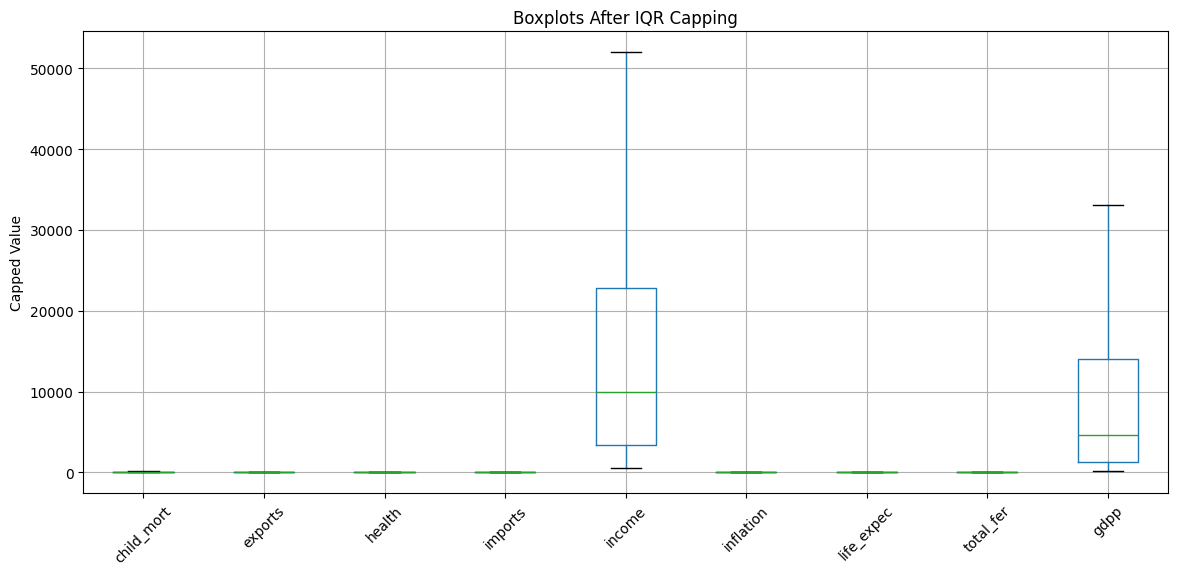

In [11]:
plt.figure(figsize=(14, 6))
X_capped.boxplot(rot=45)
plt.title('Boxplots After IQR Capping')
plt.ylabel('Capped Value')
plt.show()

## 8. Feature Scaling

Standard scaling is essential because features like `income` and `gdpp` have much larger numerical ranges than features like `life_expec`, `health`, or `total_fer`. Without scaling, large-value features would dominate the distance calculation.

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_capped)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.369802,-1.391107,0.296013,-0.047444,-0.943936,0.355270,-1.702225,1.915276,-0.846341
1,-0.550464,-0.543547,-0.091190,0.135021,-0.395181,-0.385208,0.663321,-0.862779,-0.540827
2,-0.271295,-0.053846,-0.985893,-0.713196,-0.199291,1.351551,0.686859,-0.036691,-0.508868
3,2.121210,1.071524,-1.482114,-0.146074,-0.660984,2.293979,-1.243238,2.141784,-0.589198
4,-0.714835,0.280469,-0.286671,0.642965,0.209637,-0.841463,0.722166,-0.543003,0.159686


## 9. PCA Dimensionality Reduction

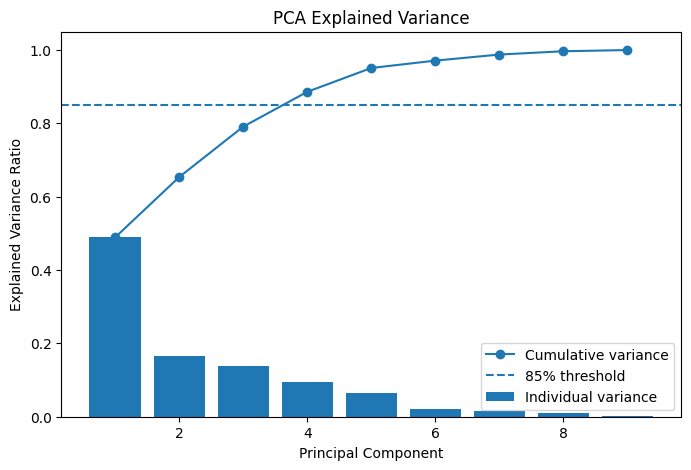

Number of components selected: 4
Cumulative variance retained: 0.8861


In [13]:
pca_full = PCA(random_state=42)
pcs_full = pca_full.fit_transform(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_var)+1), explained_var, label='Individual variance')
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', label='Cumulative variance')
plt.axhline(0.85, linestyle='--', label='85% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.legend()
plt.show()

n_components = np.argmax(cum_var >= 0.85) + 1
print('Number of components selected:', n_components)
print('Cumulative variance retained:', round(cum_var[n_components-1], 4))

In [14]:
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_cols = [f'PC{i+1}' for i in range(n_components)]
pca_df = pd.DataFrame(X_pca, columns=pca_cols)

loadings = pd.DataFrame(pca.components_.T, index=features, columns=pca_cols)
loadings.round(3)

,PC1,PC2,PC3,PC4
child_mort,-0.419,0.073,0.085,0.388
exports,0.243,0.588,-0.315,0.210
health,0.165,-0.147,0.683,0.313
imports,0.104,0.740,0.223,-0.017
income,0.409,-0.099,-0.177,0.448
inflation,-0.223,-0.124,-0.575,0.213
life_expec,0.427,-0.162,-0.108,-0.208
total_fer,-0.405,0.044,0.046,0.440
gdpp,0.405,-0.161,-0.037,0.474


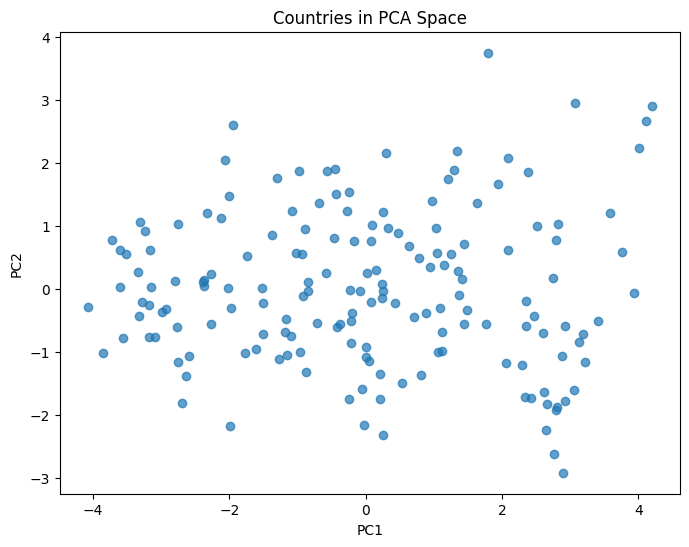

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Countries in PCA Space')
plt.show()

## 10. K-Means Clustering

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,822.509626,0.323659,1.171201,102.157806
1,3,604.938977,0.320761,1.151258,98.520779
2,4,506.977407,0.328135,1.109848,88.392523
3,5,429.498481,0.304817,1.130236,85.079371
4,6,374.568206,0.324911,1.006912,82.285339
5,7,328.653067,0.312519,1.091983,81.391092


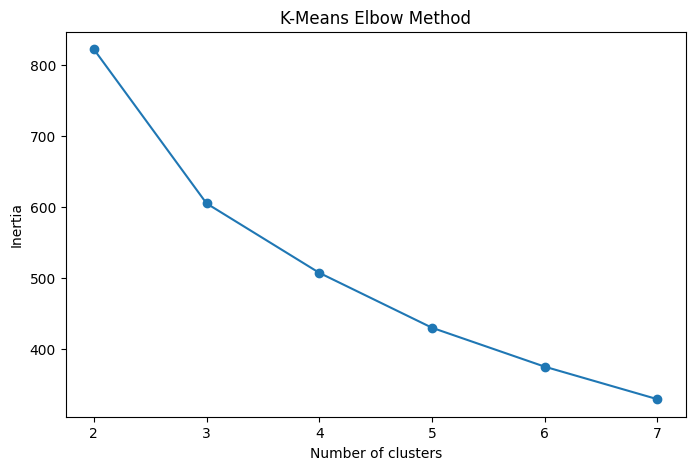

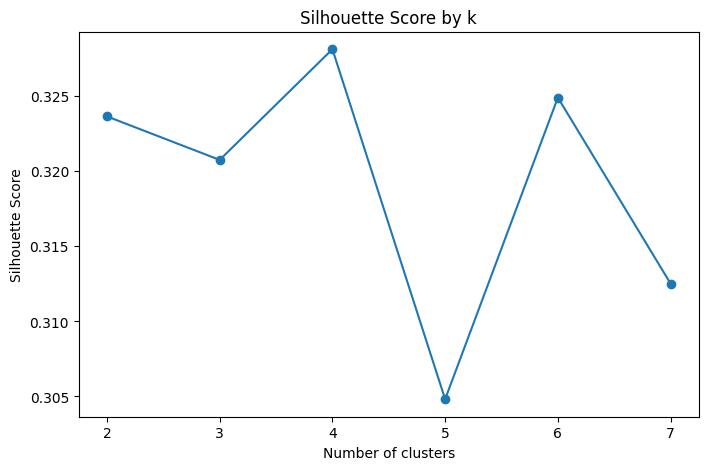

In [16]:
k_rows = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_pca)
    k_rows.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(X_pca, labels),
        'davies_bouldin': davies_bouldin_score(X_pca, labels),
        'calinski_harabasz': calinski_harabasz_score(X_pca, labels)
    })

k_eval = pd.DataFrame(k_rows)
display(k_eval)

plt.figure(figsize=(8, 5))
plt.plot(k_eval['k'], k_eval['inertia'], marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('K-Means Elbow Method')
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(k_eval['k'], k_eval['silhouette'], marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')
plt.show()

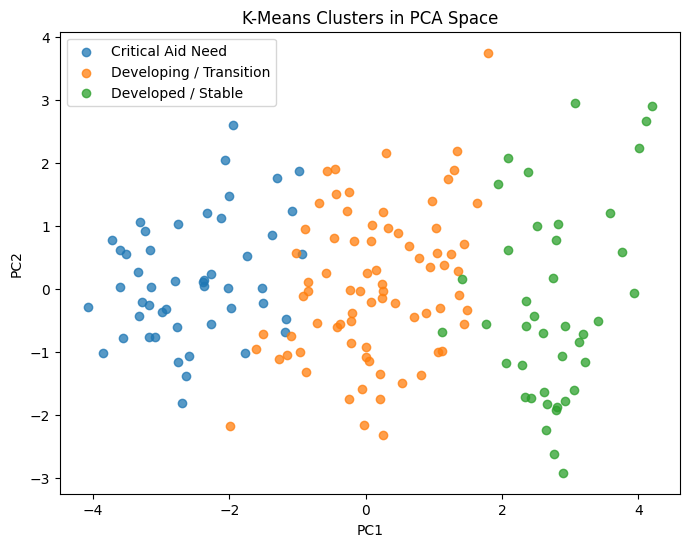

In [17]:
# Choose 3 clusters for interpretability and business usefulness
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, n_init=50, random_state=42)
k_labels_raw = kmeans.fit_predict(X_pca)

work = df.copy()
work['kmeans_raw'] = k_labels_raw

# Reorder clusters by development need
cluster_score = work.groupby('kmeans_raw').agg({
    'child_mort': 'mean',
    'gdpp': 'mean',
    'income': 'mean',
    'life_expec': 'mean'
})
cluster_score['need_score'] = (
    cluster_score['child_mort'].rank(ascending=False) +
    cluster_score['gdpp'].rank(ascending=True) +
    cluster_score['income'].rank(ascending=True) +
    cluster_score['life_expec'].rank(ascending=True)
)

order = cluster_score.sort_values('need_score').index.tolist()
mapping = {old: new for new, old in enumerate(order)}
work['kmeans_cluster'] = work['kmeans_raw'].map(mapping)
k_labels = work['kmeans_cluster'].values

segment_names = {
    0: 'Critical Aid Need',
    1: 'Developing / Transition',
    2: 'Developed / Stable'
}
work['segment'] = work['kmeans_cluster'].map(segment_names)

plt.figure(figsize=(8, 6))
for c, name in segment_names.items():
    mask = work['kmeans_cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, alpha=0.75)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters in PCA Space')
plt.legend()
plt.show()

In [18]:
kmeans_profile = work.groupby('segment')[features].mean().round(2)
kmeans_profile.insert(0, 'count', work.groupby('segment').size())
kmeans_profile

,count,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
segment,,,,,,,,,,
Critical Aid Need,49,90.81,29.27,6.42,43.45,3860.88,11.92,59.45,4.96,1885.31
Developed / Stable,41,5.65,59.07,8.42,51.63,43970.73,3.24,79.51,1.80,39612.20
Developing / Transition,77,22.20,39.08,6.21,46.56,11314.03,7.57,72.85,2.28,5825.12


In [19]:
# Representative country closest to each K-Means cluster centroid
representatives = []
for c in range(3):
    idxs = np.where(k_labels == c)[0]
    original_cluster = [old for old, new in mapping.items() if new == c][0]
    centroid = kmeans.cluster_centers_[original_cluster]
    distances = np.linalg.norm(X_pca[idxs] - centroid, axis=1)
    nearest_idx = idxs[np.argmin(distances)]
    representatives.append({
        'Segment': segment_names[c],
        'Representative Country': work.loc[nearest_idx, 'country']
    })

representatives_df = pd.DataFrame(representatives)
representatives_df

,Segment,Representative Country
0,Critical Aid Need,Benin
1,Developing / Transition,Ukraine
2,Developed / Stable,Iceland


## 11. Hierarchical Clustering

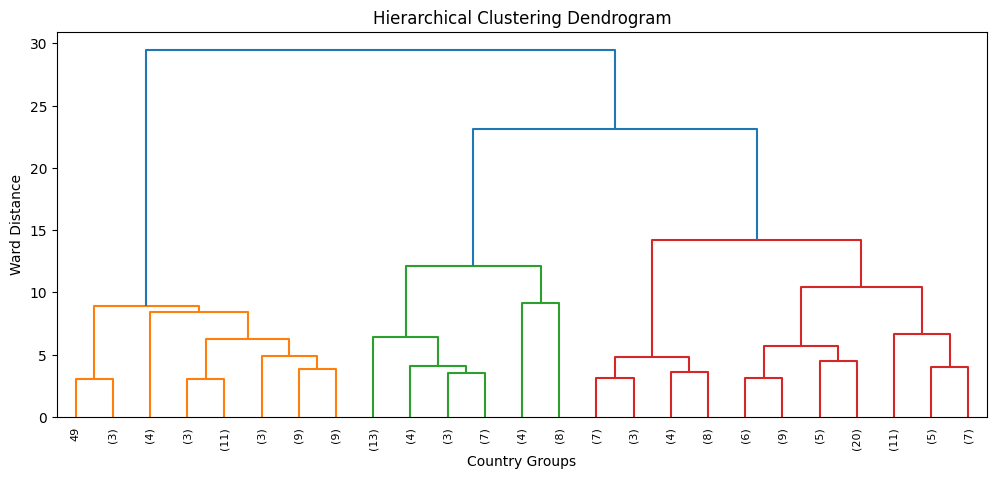

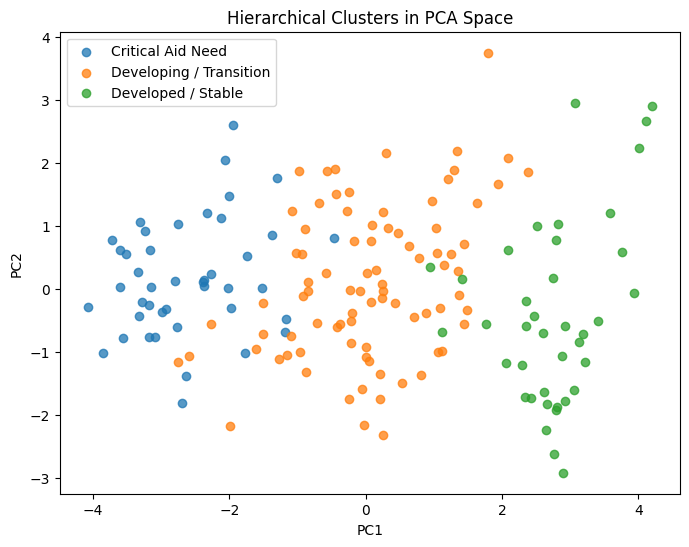

In [20]:
Z = linkage(X_pca, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=25, leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Country Groups')
plt.ylabel('Ward Distance')
plt.show()

hier = AgglomerativeClustering(n_clusters=3, linkage='ward')
h_raw = hier.fit_predict(X_pca)
work['hier_raw'] = h_raw

# Reorder hierarchical labels by need
h_score = work.groupby('hier_raw').agg({
    'child_mort': 'mean',
    'gdpp': 'mean',
    'income': 'mean',
    'life_expec': 'mean'
})
h_score['need_score'] = (
    h_score['child_mort'].rank(ascending=False) +
    h_score['gdpp'].rank(ascending=True) +
    h_score['income'].rank(ascending=True) +
    h_score['life_expec'].rank(ascending=True)
)
h_order = h_score.sort_values('need_score').index.tolist()
h_mapping = {old: new for new, old in enumerate(h_order)}
work['hier_cluster'] = work['hier_raw'].map(h_mapping)
h_labels = work['hier_cluster'].values

plt.figure(figsize=(8, 6))
for c, name in segment_names.items():
    mask = work['hier_cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, alpha=0.75)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Hierarchical Clusters in PCA Space')
plt.legend()
plt.show()

## 12. DBSCAN Clustering

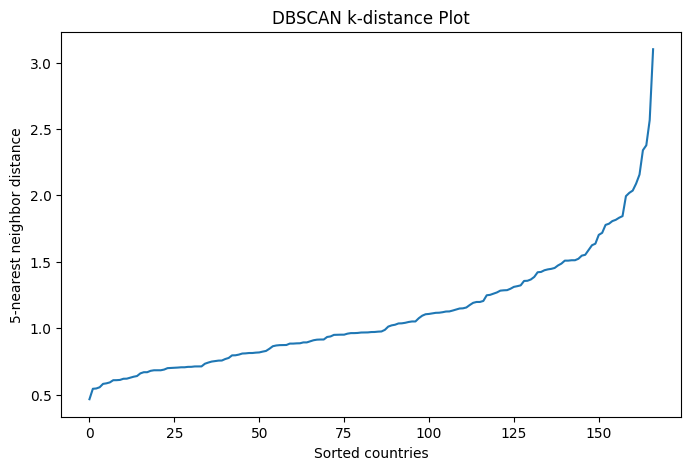

In [21]:
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)
k_dist = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_dist)
plt.xlabel('Sorted countries')
plt.ylabel(f'{min_samples}-nearest neighbor distance')
plt.title('DBSCAN k-distance Plot')
plt.show()

Candidate eps values: [1.21 1.3  1.42 1.51 1.66 1.95]
Selected eps: 1.42
DBSCAN clusters excluding noise: 2
Noise countries: 14


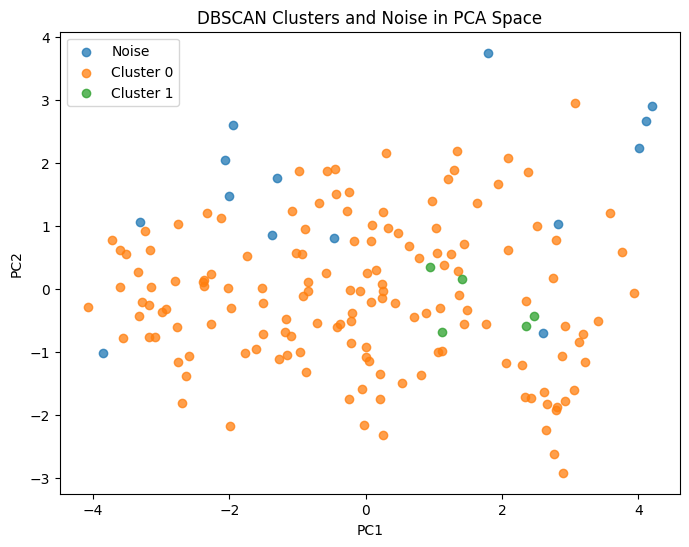

Noise countries identified by DBSCAN:


,country,child_mort,income,gdpp,life_expec
3,Angola,119.0,5900,3530,60.1
38,"Congo, Rep.",63.9,5190,2740,60.4
49,Equatorial Guinea,111.0,33700,17100,60.9
73,Ireland,4.2,45700,48700,80.4
81,Kiribati,62.7,1730,1490,60.7
87,Lesotho,99.7,2380,1170,46.5
88,Liberia,89.3,700,327,60.8
91,Luxembourg,2.8,91700,105000,81.3
101,"Micronesia, Fed. Sts.",40.0,3340,2860,65.4
113,Nigeria,130.0,5150,2330,60.5


In [22]:
# Try multiple eps values and select a practical one
candidates = np.round(np.quantile(k_dist, [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]), 2)
print('Candidate eps values:', candidates)

best_db = None
for eps in candidates:
    db_labels = DBSCAN(eps=float(eps), min_samples=min_samples).fit_predict(X_pca)
    non_noise = db_labels[db_labels != -1]
    n_clusters = len(set(non_noise))
    noise_count = int((db_labels == -1).sum())
    if n_clusters >= 2 and noise_count < len(db_labels) * 0.4:
        best_db = (float(eps), db_labels)
        break

if best_db is None:
    eps = float(np.quantile(k_dist, 0.85))
    db_labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_pca)
else:
    eps, db_labels = best_db

work['dbscan_cluster'] = db_labels
print('Selected eps:', eps)
print('DBSCAN clusters excluding noise:', len(set(db_labels[db_labels != -1])))
print('Noise countries:', int((db_labels == -1).sum()))

plt.figure(figsize=(8, 6))
for c in sorted(set(db_labels)):
    mask = db_labels == c
    label = 'Noise' if c == -1 else f'Cluster {c}'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=label, alpha=0.75)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN Clusters and Noise in PCA Space')
plt.legend()
plt.show()

print('Noise countries identified by DBSCAN:')
display(work.loc[work['dbscan_cluster'] == -1, ['country', 'child_mort', 'income', 'gdpp', 'life_expec']])

## 13. Model Evaluation and Comparison

In [23]:
metrics = []
models = {
    'K-Means': k_labels,
    'Hierarchical': h_labels,
    'DBSCAN': work['dbscan_cluster'].values
}

for name, labels in models.items():
    valid = labels != -1
    unique_clusters = set(labels[valid])
    if len(unique_clusters) > 1 and valid.sum() > len(unique_clusters):
        metrics.append({
            'Model': name,
            'Clusters': len(unique_clusters),
            'Noise': int((labels == -1).sum()),
            'Silhouette': round(silhouette_score(X_pca[valid], labels[valid]), 4),
            'Davies-Bouldin': round(davies_bouldin_score(X_pca[valid], labels[valid]), 4),
            'Calinski-Harabasz': round(calinski_harabasz_score(X_pca[valid], labels[valid]), 4)
        })
    else:
        metrics.append({
            'Model': name,
            'Clusters': len(unique_clusters),
            'Noise': int((labels == -1).sum()),
            'Silhouette': np.nan,
            'Davies-Bouldin': np.nan,
            'Calinski-Harabasz': np.nan
        })

metrics_df = pd.DataFrame(metrics)
metrics_df

,Model,Clusters,Noise,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,3,0,0.3205,1.1537,98.5625
1,Hierarchical,3,0,0.3112,1.1510,91.1144
2,DBSCAN,2,14,0.1903,0.9915,8.1664


## 14. Final Cluster Interpretation

### Segment 1: Critical Aid Need
Countries in this segment generally have high child mortality, low income, low GDPP, lower life expectancy, and higher fertility. These countries should receive priority attention for healthcare, nutrition, sanitation, education, and income-generation programs.

### Segment 2: Developing / Transition
These countries show moderate income and development indicators. They need support for infrastructure, industrial development, trade stability, employment creation, and health system improvement.

### Segment 3: Developed / Stable
These countries have high income, high GDPP, low child mortality, and high life expectancy. They are less likely to need basic aid but can contribute through climate finance, technology transfer, innovation, and global development partnerships.

## 15. Business Questions and Answers

# **1. If Standard Scaling was skipped, which features would unfairly dominate clustering?**

The features gdpp and income would have the biggest influence on clustering because their values are much larger compared to variables such as life expectancy, health expenditure, or fertility rate. As a result, the clusters would mainly be formed based on economic factors, while other important social and health indicators would receive very little importance.

# **2. Why can capping extreme high/low values be counterproductive?**

In this case study, extreme values often represent countries facing serious challenges, such as very high child mortality or extremely low income levels. If these values are capped, the severity of their situation may be reduced in the analysis. This could make it harder to identify countries that require the most urgent attention and support.

# **3. What does a high Silhouette Score imply?**

A high Silhouette Score indicates that the clustering model has performed well. Countries within the same cluster are similar to one another, while countries belonging to different clusters are clearly separated. This suggests that the identified segments are meaningful and distinct.

# **4. What unique insight does a dendrogram provide?**

A dendrogram shows how countries and clusters are related to each other at different levels. It helps us understand which groups are more closely connected and how clusters merge as the similarity threshold changes. This hierarchical view is not available in a K-Means scatter plot, which only shows the final cluster assignments.

# **5. Segment A has high income and high health spending, while Segment B has low income and low health spending. What should be the policy goal for each segment?**

For Segment A, the focus should be on improving efficiency, innovation, sustainability, and supporting global development initiatives. For Segment B, the priority should be improving access to healthcare, education, nutrition, sanitation, and creating opportunities for economic growth to improve living standards.

# **6. Why identify the representative country of a cluster?**

The representative country serves as a real-world example of the cluster's characteristics. It helps policymakers and stakeholders better understand the profile of the entire segment and makes it easier to communicate findings and recommendations in a practical way.

# **7. A cluster has high exports and imports but low GDP per capita. What recommendation would you make?**

This suggests that the countries are actively involved in international trade but may not be generating enough value from it. The focus should be on developing value-added industries, encouraging domestic manufacturing, improving trade infrastructure, and diversifying exports so that economic benefits can translate into higher income levels and overall development.

# **16. Executive Summary**

This study analyzed socio-economic indicators of countries to identify groups with similar development characteristics. After preprocessing and standardizing the data, Principal Component Analysis (PCA) was applied to reduce dimensionality while retaining most of the original information. Three clustering techniques—K-Means, Hierarchical Clustering, and DBSCAN—were evaluated.

K-Means produced the most interpretable segmentation and identified three major country groups: Critical Aid Need, Developing/Transition, and Developed/Stable countries. Hierarchical Clustering confirmed a similar structure and provided additional insight into relationships between clusters. DBSCAN was effective in detecting outlier countries but was less suitable for overall segmentation.

The analysis shows that countries in the Critical Aid Need segment require priority support in healthcare, education, nutrition, and economic development. Developing countries would benefit from investments in infrastructure, employment generation, and trade competitiveness. Developed countries should focus on innovation, sustainability, and partnership-driven support for less developed economies.

This segmentation framework can help governments, NGOs, and international organizations allocate resources more effectively and design targeted development policies.